## **Assignment**

You are required to develop a complete end-to-end data analytics mini project in Google Colab using Python, Pandas, NumPy, and Matplotlib to analyze batting and bowling performance trends in ODI cricket from 2015 to 2024. The dataset must be synthetically generated in code (minimum 500 match records) and should include realistic match attributes such as team, player, venue, runs scored, balls faced, wickets taken, overs bowled, economy rate, match result, toss decision, and date. The dataset must deliberately include missing values, inconsistent text casing, and duplicate records to simulate real-world data quality issues.

You must perform structured data inspection and profiling (including dataset shape, column types, missing value analysis, duplicate detection, and uniqueness checks), followed by systematic data cleaning (standardizing text casing, removing duplicates, handling missing values using appropriate imputation techniques including group-wise median where applicable, and converting date columns to proper datetime format). Feature engineering must be performed to create derived metrics including strike rate, boundary percentage, half-century and century indicators, batting performance bands, win flag, and year extraction for time-series analysis.

Exploratory Data Analysis (EDA) must include the creation of at least five professional-quality visualizations:

1.	Top 10 run scorers (Bar Chart)
2.	Team wins rate distribution (Pie Chart)
3.	Year-wise average strike rate trend (Line Chart)
4.	Distribution of runs scored (Histogram with density curve and milestone markers at 50 and 100)
5.	Team-wise average runs per year (Heatmap)

Advanced analysis must include:

* Toss impact on match outcome with win-rate comparison and visualization
* Identification of top all-rounders using a calculated All-Rounder Index
* Venue-based performance analysis (average runs and scoring trends)
* The project must conclude with a structured summary report displaying key findings including highest run scorer, highest wicket taker, team with best win rate, overall strike rate trend, total centuries, total half-centuries, dataset coverage statistics, and final analytical insights.

The cleaned enriched dataset and player-level summary must be exported as CSV files from Google Colab.

You must submit:

1.	Completed Google Colab Notebook (.ipynb)
2.	Exported Clean Dataset CSV
3.	Player Summary CSV
4.	Proper markdown documentation within the notebook (Title, Author, Date, Section Headings)

**Assessment Criteria**

Evaluation will be based on:

* Correct dataset generation and realism
* Proper handling of missing values and duplicates
* Logical feature engineering
* Quality and clarity of visualizations
* Accuracy of analysis and insights
* Successful export of output files



**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [ ]:
# Load dataset
df = pd.read_csv("/content/sample_data/ODI_ML_Final_5000_Records.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Year,MatchID,Venue,Team,Opposition,PlayerName,PlayerRole,InningsNumber,Runs,BallsFaced,...,BatAvg,StrikeRate_Yearly,50s_Yearly,100s_Yearly,TeamAvgTotal,Wickets_Yearly,BowlAvg,Economy_Yearly,BowlStrikeRate,5W_Hauls_Yearly
0,2022.0,2022_45,Colombo,NaN,Bangladesh,Fuqicxm Dgkemuft,All-Rounder,1.0,0.0,1.0,...,68.28,88.69,734.0,736.0,825.19,2417.0,68.28,5.27,34.94,146.0
1,2017.0,NaN,Cape Town,India,Pakistan,NaN,All-Rounder,1.0,39.0,3.0,...,65.40,86.48,740.0,733.0,829.95,2538.0,65.40,5.41,34.46,157.0
2,2023.0,2023_4,Dhaka,Australia,Bangladesh,Yfsjfvl Dxxmjvjf,All-Rounder,1.0,131.0,44.0,...,66.65,80.86,715.0,731.0,816.41,2450.0,66.65,5.06,NaN,151.0
3,2022.0,2022_32,Colombo,NaN,Sri Lanka,Rcwsnjf Fdzjquxy,All-Rounder,1.0,106.0,53.0,...,68.28,88.69,734.0,736.0,825.19,2417.0,68.28,5.27,34.94,146.0
4,2023.0,2023_60,Karachi,England,NaN,Uokkmrx Jqygzrgn,Batsman,1.0,94.0,55.0,...,66.65,80.86,715.0,731.0,816.41,2450.0,66.65,5.06,NaN,151.0


In [ ]:
# Data Inspection & Profiling
print("Shape:", df.shape)

print("\nData Types:\n", df.dtypes)

print("\nMissing Values:\n", df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nUnique Values Per Column:\n", df.nunique())

Shape: (5000, 43)

Data Types:
 Year                 float64
MatchID               object
Venue                 object
Team                  object
Opposition            object
PlayerName            object
PlayerRole            object
InningsNumber        float64
Runs                 float64
BallsFaced           float64
50s                  float64
100s                 float64
StrikeRate           float64
Dismissal             object
PowerplayRuns        float64
MiddleOversRuns      float64
DeathOversRuns       float64
MatchResult           object
Overs                float64
RunsConceded         float64
Wickets              float64
Economy              float64
BowlingStrikeRate    float64
5W_Hauls             float64
MaidenOvers          float64
ExtrasConceded       float64
Team1                 object
Team2                 object
TossWinner            object
TossDecision          object
Result                object
Matches              float64
TotalRuns            float64
BatAvg     

In [ ]:
# Data Cleaning

# Standardize Text Casing

text_cols = ["Team", "Opposition", "PlayerName", "Venue", "MatchResult", "TossDecision"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# Remove Duplicates

df = df.drop_duplicates()
print("Shape After Removing Duplicates:", df.shape)

# Handle Missing Values
# Group-wise Median

df["Runs"] = df.groupby("PlayerName")["Runs"].transform(lambda x: x.fillna(x.median()))
df['PlayerName'] = df['PlayerName'].replace('Nan', np.nan)
df["BallsFaced"] = df.groupby("PlayerName")["BallsFaced"].transform(lambda x: x.fillna(x.median()))

df["Wickets"] = df["Wickets"].fillna(df["Wickets"].median())
df["Economy"] = df["Economy"].fillna(df["Economy"].median())

# Convert Date Column
# Create a 'date' column using the existing 'Year' column
df['date'] = df['Year'].fillna(df['Year'].median()).astype(int).astype(str) + '-01-01'
df["date"] = pd.to_datetime(df["date"])
df["Year"] = df["date"].dt.year



Shape After Removing Duplicates: (4966, 49)
0       Fuqicxm Dgkemuft
1                    NaN
2       Yfsjfvl Dxxmjvjf
3       Rcwsnjf Fdzjquxy
4       Uokkmrx Jqygzrgn
              ...       
4995    Lfnxdth Kmoeaodl
4996    Tycevbv Ettejaqp
4997    Dyodxfo Nrvbvyha
4998    Wbbdhwt Firvzmdd
4999    Radmiib Jfnlnzoq
Name: PlayerName, Length: 4966, dtype: object


In [ ]:
# Strike Rate
df["Strike_Rate"] = np.where(
    df['BallsFaced'] == 0,
    0, # Set Strike_Rate to 0 if BallsFaced is 0
    (df["Runs"] / df["BallsFaced"]) * 100
)


# Milestone Indicators
df["Half_Century"] = np.where((df["Runs"] >= 50) & (df["Runs"] < 100), 1, 0)
df["Century"] = np.where(df["Runs"] >= 100, 1, 0)


# Batting Performance Bands
bins = [0,30,50,100,200]
labels = ["Low","Moderate","Good","Excellent"]
df["Performance_Band"] = pd.cut(df["Runs"], bins=bins, labels=labels)

# Clean text columns
df["Team"] = df["Team"].astype(str).str.strip()
df["MatchResult"] = df["MatchResult"].astype(str).str.strip()

# Replace 'Nan' string with actual NaN
df["MatchResult"] = df["MatchResult"].replace("Nan", np.nan)

# Create Win Flag
df["Win_Flag"] = np.where(df["Team"] == df["MatchResult"], 1, 0)

df["Win_Flag"] = np.where(
    (df["Team"] == df["MatchResult"]) &
    (~df["MatchResult"].isin(["No Result", "Tie"])),
    1,
    0
)

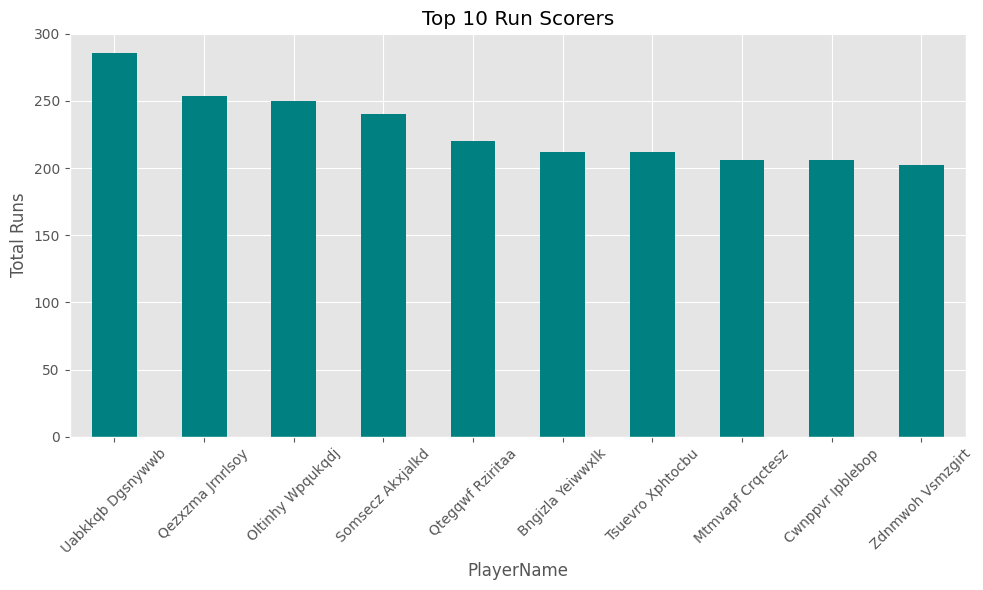

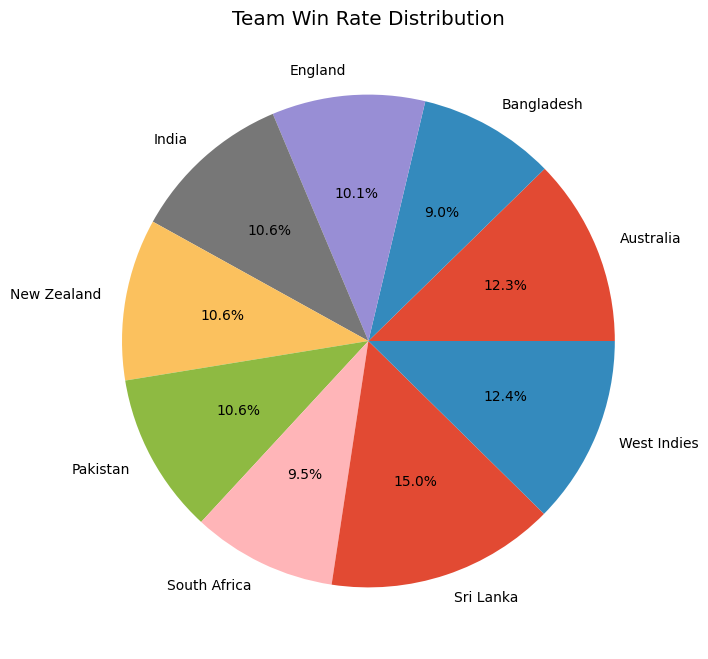

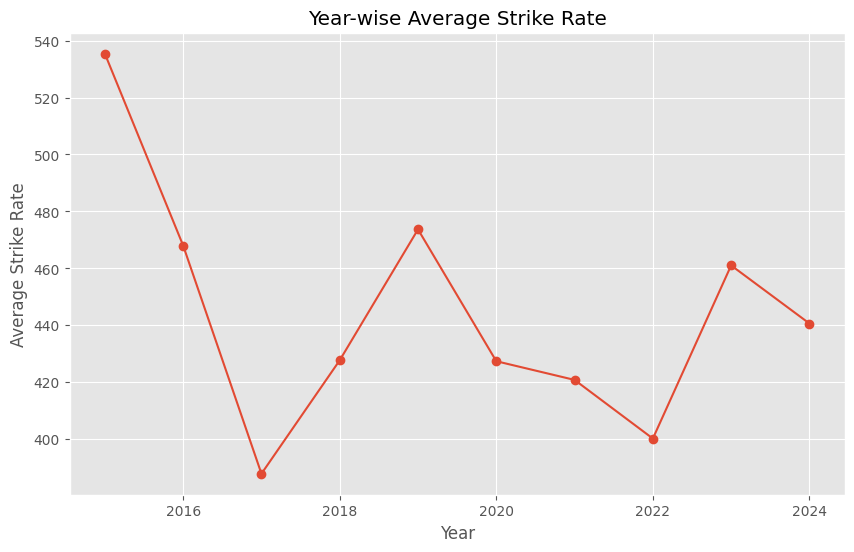

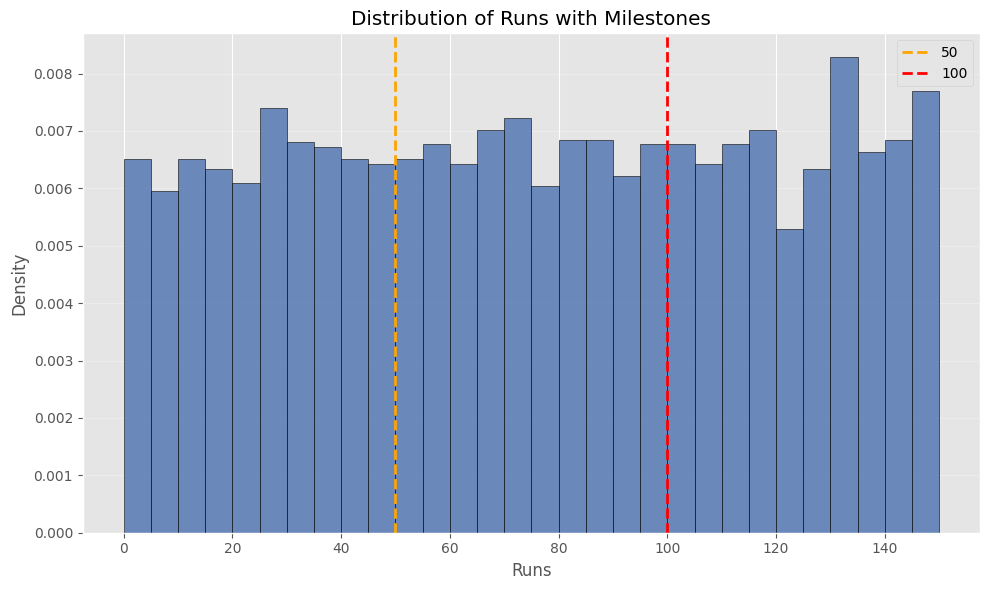

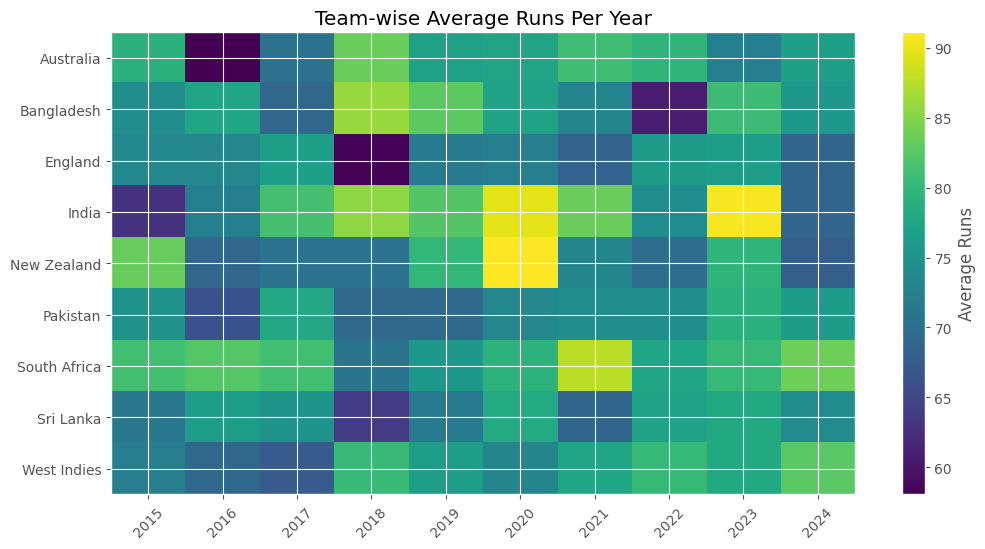

In [ ]:
# Exploratory Data Analysis

# Top 10 Run Scorers (Bar Chart)
top_scorers = df.groupby("PlayerName")["Runs"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
top_scorers.plot(kind="bar", color='teal')
plt.title("Top 10 Run Scorers")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Team Win Rate Distribution (Pie Chart)
team_win_rate = df.groupby("Team")["Win_Flag"].mean()
# Filter out 'Nan' from the index
team_win_rate = team_win_rate[team_win_rate.index != 'Nan']

plt.figure(figsize=(8,8))
plt.pie(team_win_rate, labels=team_win_rate.index, autopct="%1.1f%%")
plt.title("Team Win Rate Distribution")
plt.show()


# Year-wise Average Strike Rate (Line Chart)
year_sr = df.groupby("Year")["Strike_Rate"].mean()
plt.figure(figsize=(10,6))
plt.plot(year_sr.index, year_sr.values, marker="o")
plt.title("Year-wise Average Strike Rate")
plt.xlabel("Year")
plt.ylabel("Average Strike Rate")
plt.grid(True)
plt.show()

# Distribution of Runs (Histogram + Milestones)

runs = df["Runs"]

plt.figure(figsize=(10,6))
plt.hist(runs, bins=30, density=True, color="#4C72B0", edgecolor="black", alpha=0.8)

for x, c, lbl in [(50, "orange", "50"), (100, "red", "100")]:
    plt.axvline(x, color=c, linestyle="--", linewidth=2, label=lbl)

plt.title("Distribution of Runs with Milestones")
plt.xlabel("Runs")
plt.ylabel("Density")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Team-wise Average Runs Per Year (Heatmap using Matplotlib only)

pivot = df.pivot_table(values="Runs", index="Team", columns="Year", aggfunc="mean")

# Remove 'Nan' row from the pivot table if it exists
pivot = pivot[pivot.index != 'Nan']

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Average Runs")
plt.xticks(ticks=np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45)
plt.yticks(ticks=np.arange(len(pivot.index)), labels=pivot.index)
plt.title("Team-wise Average Runs Per Year")
plt.show()

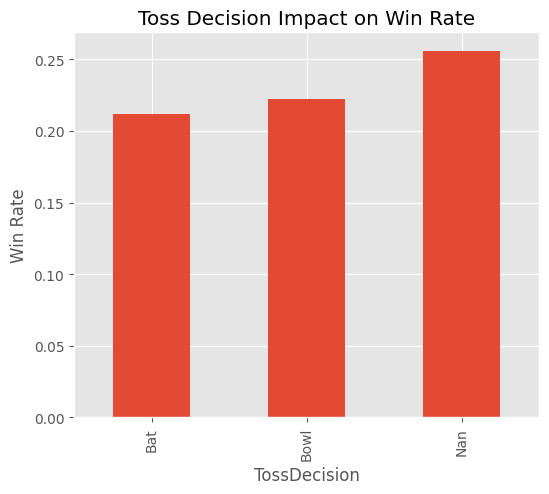

Top 10 All-Rounders:
PlayerName
Ddhtucf Srpeuqdc    275.0
Glazdrn Mbbgnvnt    275.0
Suzujzb Ktahefwl    273.0
Tenvsis Dstezxyd    272.0
Hmguzls Gzrmvvgh    271.0
Sxovxas Bwjwedfb    269.0
Ghhnbcg Cgpttsmj    267.0
Qsjaedv Qqxbfahw    266.0
Kiejmgk Muwnctwb    264.0
Fozzxyn Ozifxuqw    263.0
Name: All_Rounder_Index, dtype: float64
Top 10 High Scoring Venues:
Venue
Lords        78.461832
Nan          78.353909
Dhaka        77.848421
Melbourne    76.913941
Karachi      75.447427
Cape Town    75.160396
Colombo      75.005405
Mumbai       73.329020
Barbados     73.127098
Auckland     72.119639
Name: Runs, dtype: float64


In [ ]:
# Toss Impact on Match Outcome
toss_impact = df.groupby("TossDecision")["Win_Flag"].mean()

plt.figure(figsize=(6,5))
toss_impact.plot(kind="bar")
plt.title("Toss Decision Impact on Win Rate")
plt.ylabel("Win Rate")
plt.show()

# Top All-Rounders (All-Rounder Index)
df["All_Rounder_Index"] = df["Runs"] + (df["Wickets"] * 25)

top_all_rounders = df.groupby("PlayerName")["All_Rounder_Index"].mean().sort_values(ascending=False).head(10)

print("Top 10 All-Rounders:")
print(top_all_rounders)

# Venue-Based Performance
venue_performance = df.groupby("Venue")["Runs"].mean().sort_values(ascending=False)

print("Top 10 High Scoring Venues:")
print(venue_performance.head(10))

In [ ]:
# Final Summary Report
highest_run_scorer = df.groupby("PlayerName")["Runs"].sum().idxmax()
highest_wicket_taker = df.groupby("PlayerName")["Wickets"].sum().idxmax()
best_team = df.groupby("Team")["Win_Flag"].mean().idxmax()
total_centuries = df["Century"].sum()
total_half_centuries = df["Half_Century"].sum()

print("===== FINAL ANALYTICAL SUMMARY =====")
print("Highest Run Scorer:", highest_run_scorer)
print("Highest Wicket Taker:", highest_wicket_taker)
print("Best Win Rate Team:", best_team)
print("Total Centuries:", total_centuries)
print("Total Half Centuries:", total_half_centuries)
print("Years Covered:", df["Year"].min(), "-", df["Year"].max())
print("Total Records Analyzed:", len(df))


# Export Files
df.to_csv("Clean_ODI_Dataset.csv", index=False)

player_summary = df.groupby("PlayerName").agg({
    "Runs":"sum",
    "Wickets":"sum",
    "Strike_Rate":"mean",
    "Win_Flag":"mean"
}).reset_index()

player_summary.to_csv("Player_Summary.csv", index=False)

print("Files Exported Successfully!")

===== FINAL ANALYTICAL SUMMARY =====
Highest Run Scorer: Uabkkqb Dgsnywwb
Highest Wicket Taker: Vrzrrwu Jbqistei
Best Win Rate Team: Sri Lanka
Total Centuries: 1610
Total Half Centuries: 1577
Years Covered: 2015 - 2024
Total Records Analyzed: 4966
Files Exported Successfully!
